# HERCULES Radial Velocity Lab <br>
Written: Ethan Bull, July 2024 <br>
Last Updated: Ethan Bull, July 2024

In this lab you will learn how to measure the radial velocity of a star - how fast it is moving towards or away from us. 

The data given for this lab is wavelength-calibrated HERCULES data from MEGARA, the in-house reduction software for HERCULES. The first two cells of this lab will take the data from wavelength-calibrated echelle orders to a full 1-D spectrum. Don't worry, you do not need to understand what or how this works, it's just there for reference for the future. You'll find out the details in Understanding Spectroscopy lecture later in the course.

## Data Preparation  <br>

In [1]:
#Import neccessary python modules

%matplotlib inline
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter

from scipy.interpolate import UnivariateSpline 
from scipy.interpolate import interp1d 

from IPython.display import display, HTML

import copy

from scipy.optimize import minimize

import pandas as pd

[[4.02279653e+03 1.92963604e+00]
 [4.02281460e+03 9.57956542e-01]
 [4.02283266e+03 9.42572711e-01]
 ...
 [4.06194309e+03 9.12441846e-01]
 [4.06195995e+03 9.30362080e-01]
 [4.06197682e+03 9.73680301e-01]]
[[4.03677434e+03 1.28117804e+00]
 [4.03679295e+03 6.20738475e-01]
 [4.03681156e+03 6.20466365e-01]
 ...
 [4.09177101e+03 8.18957870e-01]
 [4.09178797e+03 8.75284517e-01]
 [4.09180492e+03 8.61137424e-01]]
[[4.06198312e+03 1.30815122e+00]
 [4.06200197e+03 1.29824708e+00]
 [4.06202082e+03 1.31448253e+00]
 ...
 [4.12158294e+03 9.45989843e-01]
 [4.12160000e+03 1.06564188e+00]
 [4.12161706e+03 9.43251853e-01]]
[[4.09121052e+03 1.19413984e+00]
 [4.09122951e+03 1.17587700e+00]
 [4.09124850e+03 1.11263004e+00]
 ...
 [4.15143140e+03 1.01013797e+00]
 [4.15144859e+03 1.09708524e+00]
 [4.15146577e+03 1.05320940e+00]]
[[4.12122800e+03 1.03258111e+00]
 [4.12124713e+03 1.05491480e+00]
 [4.12126626e+03 1.07255824e+00]
 ...
 [4.18069348e+03 9.56228176e-01]
 [4.18071082e+03 1.01881586e+00]
 [4.18072816e+

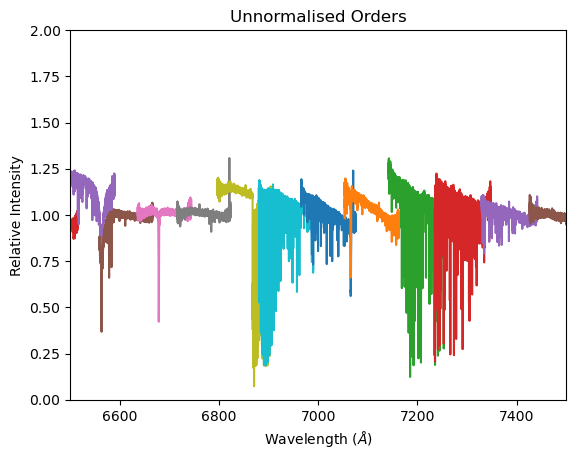

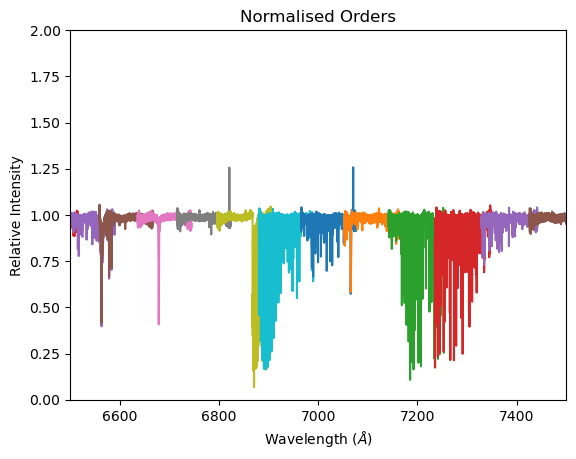

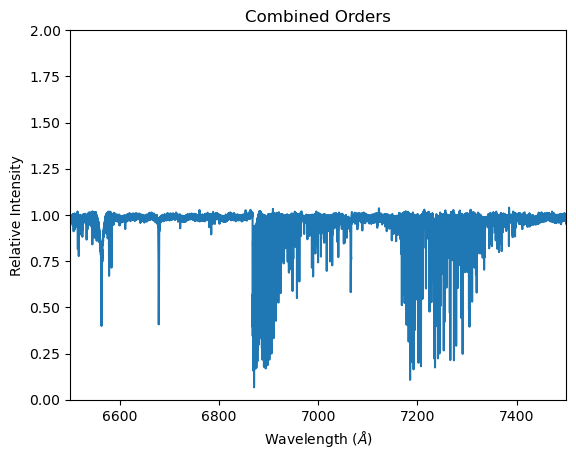

In [6]:
#Create a list of all raw data files in the folder specified by spectraDir
spectraDir = './HD16582/HD16582/'
spectraFileList = [f for f in os.listdir(spectraDir) if f.endswith('.mat')]
spectraFileList.sort()

file = spectraFileList[2]

# A function to extract the orders from a .mat file, and apply barycentric correction.
def extractOrdersFromFile(filename):
    '''A function to extract a HERCULES spectrum from the .mat format files. Applies barycentric correction.
    
        inputs: filename (string)
        outputs: spectral orders (list)
                 julian date (float)'''
    
    #Use scipy loadmat function to load the .mat file
    dat = loadmat(filename)
    

    #The file contents are loaded into the dictionary 'dat', 
    #with the file contents saved in a key that corresponds 
    #to the filename. This part of the code extracts the
    #key for the dictionary from the file name
    fileString = filename[-12:-4]
    
    #Extract the Julian Date from the dictionary
    jD = dat[fileString][0,0][-7][0][0]
    
    #Extract the barycentric correction from the dictionary
    baryCor = dat[fileString][0,0][-1][0][0]

    #Create an empty list that will hold the orders of the spectrum
    orders = []

    #Iterate through the dictionary and extract the spectral orders
    for i in range(len(dat[fileString][0,0])-8):

        #Extract the ith spectral orders
        data = dat[fileString][0,0][i]
        
        #Grab the wavelength from the extracted order and apply the 
        #barycentric correction
        wavelength = data[:,0]*(2.99792458e5 + baryCor)/(2.99792458e5)
        print(data)
        #Grab the intensity from the extracted order
        intensity = data[:,1]

        #Pack the  barycentric corrected wavelength and intensity 
        #of the extracted spectral order into a tuple, then add that to the list 
        #of extracted orders
        orders.append((wavelength,intensity))

    
    return orders, jD

orders, jD = extractOrdersFromFile(spectraDir+file)

# A simple function to visulise spectra, including plotting multiple plots easily
def SpectrumPlot(orders, spectraid = None, xlim = [6500,7500], ylim = [0.0,2.0], figure_num = None):
    '''A function to plot a list of spectral orders. If more than one set of orders is supplied, 
            they can be identified with the idList input.

    inputs:  spectral orders    :   list of lists
             spectra id         :   list of strings
             figure_num         :   int
    outputs: none'''


    for i, spectra in enumerate(orders):
    #Create an empty figure
        if figure_num is not None:
            plt.figure(figure_num)
        else:
            plt.figure()
        
        #Set the x and y limits of the plot
        plt.ylim(ylim)
        plt.xlim(xlim)
        
        #Iterate through the orders of the selected spectrum and add them to the plot
        for j, data in enumerate(spectra):
            #Plot the order on the axis as wavelength v.s. intensity
            plt.plot(data[0],data[1])
        if spectraid is not None:
            plt.title(spectraid[i])
            
        #Update labels on plot
        plt.xlabel(r'Wavelength ($\AA$)')
        plt.ylabel('Relative Intensity')
        if figure_num is None:
            plt.show()


# Normalising each order
def normaliseOrders(orders,scale = 20,intensityLimit = 20.0,polynomialOrder = 4):
    '''A function to continuum normalise a list of orders. 
        The function chooses continuum points by maximum filtering the data and applying a direct threshold.
        The size of the maximum filter and the intensity threshold can be controlled by the relevant input 
        parameters. The continuum is determined by fitting a polynomial to the  previously selected continuum 
        points.The continuum points are first median filtered to remove any outliers, the median filter is the 
        same size as the maximum filter. The order of the polynomial can be controlled by the relevant input 
        parameter.

    inputs:  spectral orders (list)
             maximum/median filter scale (integer)
             intensity threshold (float)
             polynomial order (int)
    outputs: normalised spectral orders (list)'''
    
    #Create an empty list to hold the continuum normalised spectrum for each spectral order
    normalisedOrders = []

    #Iterate through the spectral orders...
    for i in range(len(orders)):

        #Grab the wavelength and intensity of the ith order
        wavelength = orders[i][0]
        intensity = orders[i][1]

        #Maxmimum filter the intensity, which finds the maxmimum in a window
        #of size scale centrered on each pixel
        maximaIntesnity = maximum_filter(intensity,scale)
        
        #Identify points in the intensity that are considered part of the continuum
        #by choosing points where the intensity is equal to the maximum filtered intensity 
        # (akin to choosing local maxima within the windows) that are also below a chosen 
        #intensity limit
        continuumMask = (maximaIntesnity == intensity)*(intensity < intensityLimit)
        
        #If the above process does not identify any continuum points, break the process
        if(np.all(~continuumMask)):
            print('Error: No Continuum Points Found. Try a different set of parameters')
            break
            
        #Fit a polynomial to the chosen continuum points. A median filter is applied to the chosen continuum 
        #points to exclude any outliers.
        continuumFit = np.polyfit(wavelength[continuumMask], median_filter(intensity[continuumMask],scale),polynomialOrder)


        #Apply the continuum normalisation to the spectral order, then add it to the list
        normalisedOrders.append((wavelength,intensity/np.polyval(continuumFit,wavelength)))
    
    return normalisedOrders

normalisedOrders = normaliseOrders(orders, scale=20, intensityLimit = 20.0,polynomialOrder = 4)

# Merging orders into one spectrum
def combineOrders(orders, smoothingWindow=10,scale=1.0):
    
    '''A function to combine the spectral orders into a single continuous spectrum.
        Where the orders overlap, a arctangent wavelength weighted mean is used.

    inputs:  spectral orders (list)

    outputs: combined spectrum (list)'''
    
    #Create empty lists to hold the spectral orders that are ready to be combined
    wavelengthList = []
    intensityList = []
    
    #Create a copy of the spectral orders so that the original orders are not altered
    iOrders = copy.deepcopy(orders)
    
    for i in range(len(iOrders)-1):
        
        
        #Determine the wavelength limits of the ith and i+1th spectral orders to 
        #determine the range of wavelengths that have the orders overlapping
        wavelengthLowBoundary = np.min(iOrders[i+1][0])
        wavelengthUpBoundary = np.max(iOrders[i][0])
        meanBoundaryWL = (wavelengthLowBoundary+wavelengthUpBoundary)/2.0
        

        #If the neighbouring orders overlap...
        if(wavelengthLowBoundary < wavelengthUpBoundary):


            #Copy the intensity and wavelength of the lower order into a dummy variable
            wavelengthLowerOrder = iOrders[i][0]
            intensityLowerOrder = iOrders[i][1]

            #Copy the intensity and wavelength of the higher order into a dummy variable
            wavelengthHigherOrder = iOrders[i+1][0]
            intensityHigherOrder = iOrders[i+1][1]


            #Select ot the data in the overlapping region from the higher and lower order
            lowOrderMask = (wavelengthLowerOrder <= wavelengthUpBoundary)*(wavelengthLowerOrder >= wavelengthLowBoundary)
            highOrderMask = (wavelengthHigherOrder <= wavelengthUpBoundary)*(wavelengthHigherOrder >= wavelengthLowBoundary)

            #Create a new common wavelength grid for the overlapping region
            overlapWavelength = np.linspace(wavelengthLowBoundary, wavelengthUpBoundary, np.max([np.sum(lowOrderMask), np.sum(highOrderMask)]))

            #Linearly interpolate the lower and higher order spectral orders onto the comman wavelength grid
            olintensityLOInterp = interp1d(wavelengthLowerOrder[lowOrderMask],intensityLowerOrder[lowOrderMask],kind='linear',bounds_error=False,fill_value='extrapolate')(overlapWavelength)
            olintensityHOInterp = interp1d(wavelengthHigherOrder[highOrderMask],intensityHigherOrder[highOrderMask],kind='linear',bounds_error=False,fill_value='extrapolate')(overlapWavelength)

            #Weight the overlapping orders using an arctangent function
            weights = np.arctan((overlapWavelength - meanBoundaryWL)/scale)/(np.pi) + 0.5

            #Calculate the new overlap as the weighted average between the overlapping orders
            overlapIntensity = weights*olintensityHOInterp + (1-weights)*olintensityLOInterp
            
            #Remove the overlapping region from the original spectral orders and add in the new weighted
            #average in the overlapping area
            lowOrderWL = np.concatenate((wavelengthLowerOrder[wavelengthLowerOrder<wavelengthLowBoundary],
                                          overlapWavelength[overlapWavelength < meanBoundaryWL ]))
            lowOrderI = np.concatenate((intensityLowerOrder[wavelengthLowerOrder<wavelengthLowBoundary],
                                          overlapIntensity[overlapWavelength < meanBoundaryWL ]))            
            iOrders[i] = (lowOrderWL,lowOrderI)            
            highOrderWL = np.concatenate((overlapWavelength[overlapWavelength >= meanBoundaryWL ],
                                          wavelengthHigherOrder[wavelengthHigherOrder>wavelengthUpBoundary]))
            highOrderI = np.concatenate((overlapIntensity[overlapWavelength >= meanBoundaryWL ],
                                         intensityHigherOrder[wavelengthHigherOrder>wavelengthUpBoundary]))
            iOrders[i+1] = (highOrderWL,highOrderI)


        

        #Add the spectral orders that are now ready to be combined to the list of 
        #spectral orders that are ready to be combined
        wavelengthList.append(iOrders[i][0])
        intensityList.append(iOrders[i][1])

            

    #Add the last spectral order
    wavelengthList.append(iOrders[-1][0])
    intensityList.append(iOrders[-1][1])
    
    #Concatenate the list of spectral orders into one combined spectrum
    combinedOrderList = [np.hstack(wavelengthList), np.hstack(intensityList)]
    
    return(combinedOrderList)

combinedOrders = combineOrders(normalisedOrders)


# To plot everything
SpectrumPlot([orders, normalisedOrders,[combinedOrders]],['Unnormalised Orders', 'Normalised Orders','Combined Orders'])

## Task 1

We can plot the spectrum output of above code using the SpectrumPlot function defined above. The input are:
1. the spectrum (which is combinedOrders, the list of lists generated above), and 
2. name for the spectrum (also as a list of strings). 

We can also define our x-limits (wavelength) and y-limits (relative intensity) easily with this function.

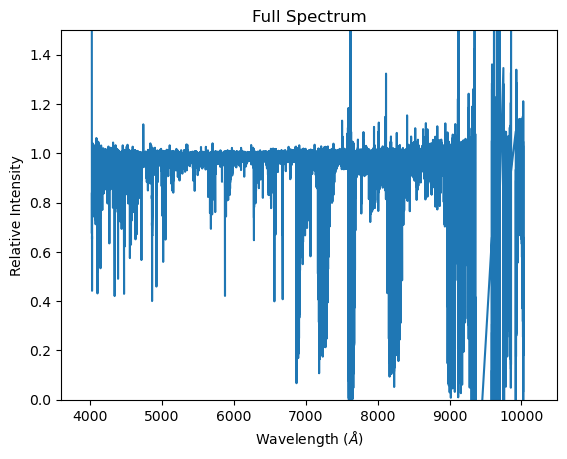

In [7]:
SpectrumPlot([[combinedOrders]], spectraid = ['Full Spectrum'], xlim = [3600,10500], ylim = [0.0,1.5], figure_num = None)

This is a full spectrum from HERCULES. There is a lot in it and it may look a little overwhelming. 

We want to zoom in to a section between 6500 and 6650 Angstroms.<br>
Use the SpectrumPlot function to zoom in on this section of the spectrum.<br>

Do you think the part of the spectrum you are looking at would cause any issues for data analysis? Why or why not? What could cause issues?

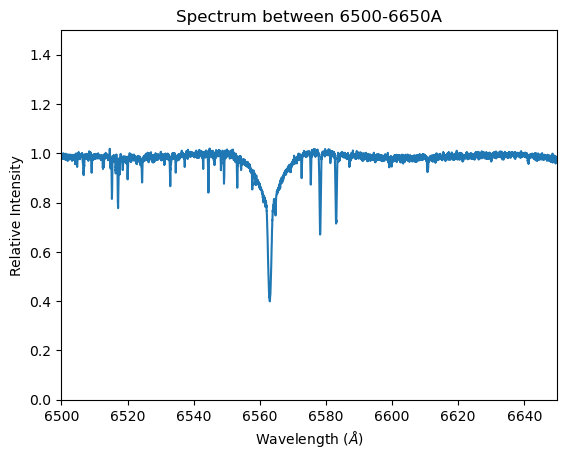

In [18]:
SpectrumPlot([[combinedOrders]], spectraid = ['Spectrum between 6500-6650A'], xlim = [6500,6650], ylim = [0.0,1.5], figure_num = None)

## Task 2

We will now learn how to take a measurement from a spectrum. 

A common value measured from a spectrum is radial velocity.  This is done by measuring the observed position of a spectral line, and comparing it to the wavelength of that line that we would expect from the laboratory rest-frame. 

To measure the position of a spectral line, we pick our spectral line and fit a Gaussian to it. This measurement also gives us information about the shape and strength of the line. <br>

The following cell contains three functions which altogether fit a Gaussian to a spectral line.

The output is a dataframe of the gaussian parameters and their errors.

In [14]:
def chi2(p,model,yData,xData,yErr):
    '''A function to calculate the chi squared test statistic for the Gaussian absorption line fitting'''
    m = model(p, xData)
    return np.sum((yData - m)**2/yErr**2)

def gaussianLine(p,x):
    '''A function to calculate a Gaussian absorption line. Returns y values of the fit associated to the input x values'''
    A, mu, sigma, C = p
    return(A*np.exp(-0.5*(x - mu)**2/sigma**2) + C)

def fitGaussianLine(spectrum, wavelengthWindow, lineName=None):
    
    '''A function to fit a single Gaussian to a fixed region of the spectrum. Multiple regions can be fitted
        with a single call by suppling a list of wavelength limits. By default, this function plots the result,
        this can be toggled off by setting plotFit = False.

    inputs: combined spectrum (list)
            fitting windows (tuple e.g (lambda_min,lambda_max), or list of tuples) 
            line name (list of string)

    outputs: pandas DataFrame of fitted parameters (ndarray with shape (len(wavelengthWindow),4))'''
    
    #Ceate empty lists to store the fitted parameters and errors
    fitList = []
    errorList = []
    
    #Grab the wavelength and intensity of the spectrum
    wavelength = spectrum[0]
    intensity = spectrum[1]
    
    #Create a mask to select only data in the wavelength window
    waveMask = (wavelength > np.min(wavelengthWindow))*(wavelength < np.max(wavelengthWindow) )

    #Use the mask to select only the data in the wavelength window
    wData = wavelength[waveMask]
    iData = intensity[waveMask]
    
    #Smartly choose initial guesses for the Guassian absorption lines parameters
    #mu: the central wavelength of the absorption line
    #A: the depth of the absorption line
    #C: the offset of the line from 0, should be about 1 (so it's on the continuum)
    #sigma: the width of the absorption line
    muGuess = wData[np.argmin(iData)]
    AGuess =  np.min(iData) - 1.0
    CGuess = 1.0
    sigmaGuess = 1.0
    
    #Estimate a value for the uncertainty in the intensity measurements
    yerrGuess = 0.01
    
    #Fit the Gaussian absorption line using scipys minimize function to minimize chi2 function.
    initialGuess = [AGuess,muGuess, sigmaGuess,CGuess]
    fit = minimize(chi2, x0=initialGuess, args = (gaussianLine,iData,wData,yerrGuess), method='BFGS')
    
    #Rescale the errorbars on the parameters to account for the fact that we don't
    #know what the error on the measuremed spectrum is
    #We do this by asserting that our fit has a reduced chi squared of ~1.
    mChi2 = chi2(fit.x,gaussianLine,iData,wData,yerrGuess)
    pErr = np.sqrt(np.diag(0.5*fit.hess_inv*mChi2))
    
    #Save the fitted parameters into a new variable
    pFit = fit.x

    #Create a new wavelength array for plotting the result
    plotLineX = np.linspace(pFit[1]-5*pFit[2],pFit[1]+5*pFit[2],1000)

    
    #If the result is being plotted and its the first window...

    
    #Add the fitted parameters and errors to the lists
    fitList.append(pFit)
    errorList.append(pErr)

    #Combine the fit results from each window into a pandas DataFrame
    fit = np.vstack(fitList)
    error = np.vstack(errorList)
    df = pd.DataFrame(np.hstack([fit,error]), columns=['A','mu','sigma','C','A_Err','mu_Err','sigma_Err','C_Err'],index=lineName)

    return(df)


Using the above function, fitGaussianLine, fit a gaussian to the H-alpha absorption line. The H-alpha line lies between approximately 6520 and 6600 angstroms.

Print the resulting parameters. Don't forget to name the line.

In [24]:
params = fitGaussianLine(combinedOrders, [6520, 6600])
print(params)

          A           mu     sigma         C     A_Err    mu_Err  sigma_Err  \
0 -0.382643  6563.010505  1.613942  0.975465  0.189569  0.653739   1.296965   

      C_Err  
0  0.023345  


Plot the region of spectrum you are fitting and use the gaussianLine function to plot your Gaussian fit on top of the spectrum. The 'figure_num' option in SpectrumPlot allows you to set a figure number to allow multiple plots in one figure.

To extract the parameters from the pandas dataframe, for example for the 'A' value for the 'Halpha' line, use: </br>
A_halpha = df_halpha.loc['Halpha','A']

Define an x-vector of wavelengths to use in gaussianLine.

[-3.82642736e-01  6.56301051e+03  1.61394193e+00  9.75464671e-01
  1.89568684e-01  6.53738972e-01  1.29696520e+00  2.33448521e-02]


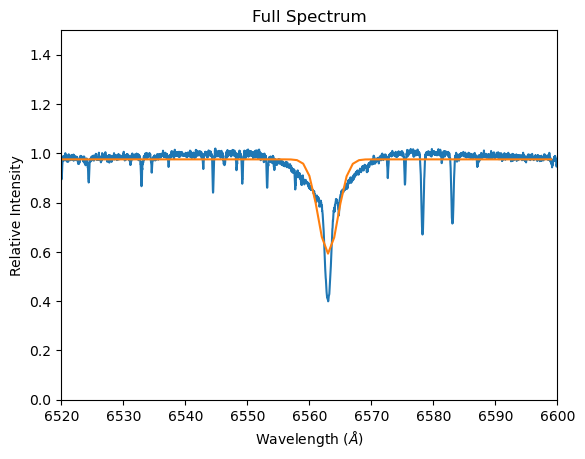

In [32]:
plotparams = params.to_numpy()
print(plotparams[0])
SpectrumPlot([[combinedOrders]], spectraid = ['Full Spectrum'], xlim = [6520,6600], ylim = [0.0,1.5], figure_num = 1)
x = np.arange(6520, 6600)
plt.plot(x, gaussianLine(plotparams[0][:4], x))
plt.show()

Do you think this is a good fit? Discuss with a tutor.

Now extract the central wavelength value ('mu') from the Gaussian fit dataframe. 

Convert this to a radial velocity using the equation:<br>
$$v_{rad} = (\frac{\lambda}{\lambda_{0}}-1)c$$
where $\lambda$ is the central wavelength, $\lambda_{0}$ is the reference wavelength, and $c$ is the speed of light. 

Look up the H_alpha reference wavelength here: [Fraunhofer lines](https://en.wikipedia.org/wiki/Fraunhofer_lines)

What is the uncertainty? Use the 'error' from the Gaussian fit dataframe to propagate an uncertainty.

In [51]:
centre = plotparams[0][1]
print(centre)

c = 3 * 10 ** 8
lambda0 = 656.281 * 10
v_rad = (centre/lambda0 - 1) * c
print(v_rad)
v_rad_uncertainty = (v_rad/lambda0) * params['mu_Err'].to_numpy()[0]
print(v_rad_uncertainty)

6563.0105050349375
9165.511493036682
0.9130009948654332


Now, we want to compare your value with the reference value on your spectral line plot.

Replot the spectral line and use [plt.axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) to:

1. indicate the centre of your spectral line, and 
2. indicate the location of the reference line.

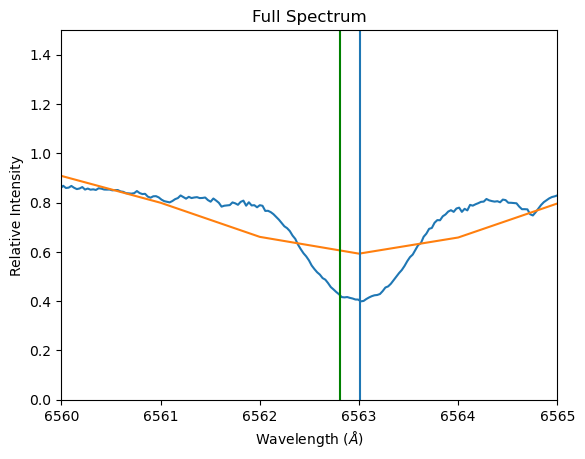

In [50]:
SpectrumPlot([[combinedOrders]], spectraid = ['Full Spectrum'], xlim = [6560,6565], ylim = [0.0,1.5], figure_num = 1)
x = np.arange(6520, 6600)
plt.plot(x, gaussianLine(plotparams[0][:4], x))
plt.axvline(lambda0, color='green')
plt.axvline(centre)
plt.show()

## Task 3

Repeat Task 2 for two or three more [Fraunhofer lines](https://en.wikipedia.org/wiki/Fraunhofer_lines), such as the Helium $D_3$ lines and one of the Sodium $D$ doublet lines. 

Do these lines give the same radial velocity? Why or why not?

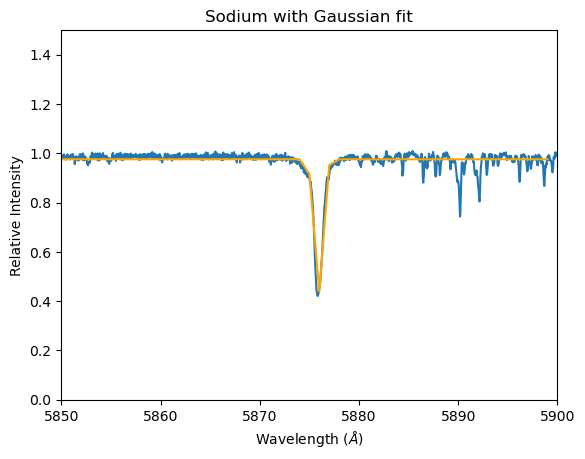

5875.913196192923
15072.262675541737
0.5003712986613782


In [68]:
params = fitGaussianLine(combinedOrders, [5850,5900])
plotparams = params.to_numpy()

SpectrumPlot([[combinedOrders]], spectraid = ['Sodium with Gaussian fit'], xlim = [5850,5900], ylim = [0.0,1.5], figure_num = 1)
x = np.arange(5850, 5900)
plt.plot(x, gaussianLine(plotparams[0][:4], x), color='orange')
plt.show()
centre = plotparams[0][1]
print(centre)
c = 3 * 10 ** 8
lambda0 = 587.5618 * 10
v_rad = (centre/lambda0 - 1) * c
print(v_rad)
v_rad_uncertainty = (v_rad/lambda0) * params['mu_Err'].to_numpy()[0]
print(v_rad_uncertainty)

## Task 4

The star HD16582 is actually a pulsating star, meaning its surface moves in and out. This movement is measureable in the spectral lines and affects the radial velocity measured for each line. Hence you can see differences in radial velocity between lines.

For each of the three lines you measured earlier, make a timeseries of the radial velocity by measuring the lines for every observation. 

You will need to get the Julian Date (JD) from the header, and iterate through each file to get the timeseries measurements required.

 HINTs:
 1. You need your list of files to iterate through. Use the file organisation code from Lab 1.
 2. For each file, you can extract the full spectrum by running the code below. 
 3. Use your code from Task 3 to measure the radial velocity for each line in each spectrum.
 
 


In [ ]:
orders, jD = extractOrdersFromFile(spectraDir+file)
normalisedOrders = normaliseOrders(orders, scale=20, intensityLimit = 20.0,polynomialOrder = 4)
combinedOrders = combineOrders(normalisedOrders)

## Task 5 - Extra

Can you figure out the pulsation period from this data? Discuss how you might do it with a tutor.